In [ ]:
import time, matplotlib.pyplot as plt
import multiprocessing
import os
import psutil
import platform
import cpuinfo  

# --- Core information ---
physical_cores = psutil.cpu_count(logical=False)
logical_cores = psutil.cpu_count(logical=True)
print(f"Physical cores: {physical_cores}")
print(f"Logical cores: {logical_cores}")

# --- Frequency ---
freq = psutil.cpu_freq()
print(f"Base frequency: {freq.min:.2f} MHz")
#print(f"Current frequency: {freq.current:.2f} MHz")
print(f"Max frequency: {freq.max:.2f} MHz")

# --- CPU usage (per-core and total) ---
"""print("CPU usage per core:", psutil.cpu_percent(percpu=True))
print("Total CPU usage:", psutil.cpu_percent())"""

# --- Cache & architecture / instruction sets ---
info = cpuinfo.get_cpu_info()
print(f"Architecture: {info['arch']}")
print(f"Bits: {info['bits']}")
print(f"Brand: {info['brand_raw']}")
print(f"Hz_advertised: {info['hz_advertised_friendly']}")
print(f"Hz_actual: {info['hz_actual_friendly']}")
print(f"Flags (instruction sets): {info['flags']}")  # AVX, SSE, etc.

# --- OS and platform info ---
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")

Physical cores: 6
Logical cores: 12
Base frequency: 0.00 MHz
Max frequency: 3301.00 MHz
Architecture: X86_64
Bits: 64
Brand: AMD Ryzen 5 6600H with Radeon Graphics
Hz_advertised: 3.2940 GHz
Hz_actual: 3.3010 GHz
Flags (instruction sets): ['3dnow', '3dnowext', '3dnowprefetch', 'abm', 'adx', 'aes', 'apic', 'avx', 'avx2', 'bmi1', 'bmi2', 'clflush', 'clflushopt', 'clwb', 'cmov', 'cmp_legacy', 'cr8_legacy', 'cx16', 'cx8', 'de', 'dts', 'erms', 'f16c', 'fma', 'fpu', 'fxsr', 'ht', 'hypervisor', 'ia64', 'invpcid', 'lahf_lm', 'mca', 'mce', 'misalignsse', 'mmx', 'monitor', 'movbe', 'msr', 'mtrr', 'osvw', 'osxsave', 'pae', 'pat', 'pclmulqdq', 'perfctr_core', 'pge', 'pni', 'popcnt', 'pqe', 'pqm', 'pse', 'pse36', 'rdpid', 'rdrnd', 'rdseed', 'sep', 'sepamd', 'serial', 'sha', 'smap', 'smep', 'ss', 'sse', 'sse2', 'sse4_1', 'sse4_2', 'sse4a', 'ssse3', 'tm', 'topoext', 'tsc', 'umip', 'vaes', 'vme', 'vpclmulqdq', 'wdt', 'xsave']
Platform: Windows 11
Processor: AMD64 Family 25 Model 68 Stepping 1, Authenti

1.0s | CPU: 596.90% ≈ 5.97 cores
2.0s | CPU: 585.90% ≈ 5.86 cores
3.0s | CPU: 581.30% ≈ 5.81 cores
4.0s | CPU: 598.40% ≈ 5.98 cores
5.0s | CPU: 590.60% ≈ 5.91 cores
6.0s | CPU: 609.40% ≈ 6.09 cores
7.0s | CPU: 587.50% ≈ 5.88 cores
8.0s | CPU: 584.40% ≈ 5.84 cores
9.0s | CPU: 298.40% ≈ 2.98 cores
10.0s | CPU: 100.00% ≈ 1.00 cores
11.0s | CPU: 100.00% ≈ 1.00 cores
12.0s | CPU: 100.00% ≈ 1.00 cores
13.0s | CPU: 95.30% ≈ 0.95 cores
14.0s | CPU: 100.00% ≈ 1.00 cores
15.0s | CPU: 98.40% ≈ 0.98 cores
16.0s | CPU: 98.40% ≈ 0.98 cores
17.0s | CPU: 100.00% ≈ 1.00 cores
18.0s | CPU: 100.00% ≈ 1.00 cores
19.0s | CPU: 100.00% ≈ 1.00 cores
20.0s | CPU: 101.60% ≈ 1.02 cores
21.0s | CPU: 98.40% ≈ 0.98 cores
22.0s | CPU: 100.00% ≈ 1.00 cores
23.0s | CPU: 100.00% ≈ 1.00 cores
24.0s | CPU: 100.00% ≈ 1.00 cores
25.0s | CPU: 98.40% ≈ 0.98 cores
26.0s | CPU: 100.00% ≈ 1.00 cores
27.0s | CPU: 100.00% ≈ 1.00 cores
28.0s | CPU: 100.00% ≈ 1.00 cores
29.0s | CPU: 100.00% ≈ 1.00 cores
30.0s | CPU: 98.40% ≈ 0.98 c

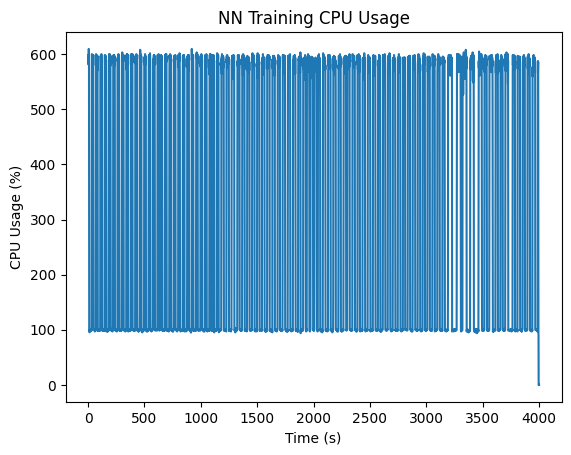

In [4]:
pid = 20512
process = psutil.Process(pid)

times, usages = [], []
start = time.time()

try:
    while True:
        usage = process.cpu_percent(interval=1)  # % CPU
        elapsed = time.time() - start
        times.append(elapsed)
        usages.append(usage)
        print(f"{elapsed:.1f}s | CPU: {usage:.2f}% ≈ {usage/100:.2f} cores")

except KeyboardInterrupt:
    print("Stopped monitoring")

# Plot after stopping
plt.plot(times, usages)
plt.xlabel("Time (s)")
plt.ylabel("CPU Usage (%)")
plt.title("NN Training CPU Usage")
plt.show() 